In [375]:
#!C:\Program Files\Python313\python.exe


"""
PROJECT 1
"""
__author__ =  'COMP3800 P01'
__version__ = 'Fall 2025'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


"""
Preview
"""
df = pd.read_csv('salaries.csv')

# Show all columns
pd.set_option('display.max_columns', None)

# Print first 5 rows
print(df.head(5))

   work_year experience_level employment_type           job_title  salary  \
0       2024               EN              FT  Research Associate   35000   
1       2024               SE              FT           Data Lead  117600   
2       2024               SE              FT           Data Lead   78000   
3       2024               SE              FT             Analyst   91500   
4       2024               SE              FT             Analyst   70000   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             GBP          43750                 GB            50   
1             EUR         130666                 NL             0   
2             EUR          86666                 NL             0   
3             USD          91500                 US             0   
4             USD          70000                 US             0   

  company_location company_size  
0               GB            L  
1               NL            M  
2               NL  

In [376]:
"""
Task 1: Handle Missing Data & Print Summary Stats
"""
# 🔍 Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# 🧹 Drop rows with any missing values
df_cleaned = df.dropna()

print(f"\nRemaining entries after dropping incomplete rows: {df_cleaned.shape[0]}")

# 📊 Summary statistics for numeric columns
print("\nSummary statistics (numeric):")
print(df_cleaned.describe())

# 📋 Summary statistics for categorical columns
print("\nSummary statistics (categorical):")
print(df_cleaned.describe(include='object'))

Missing values per column:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Remaining entries after dropping incomplete rows: 43331

Summary statistics (numeric):
          work_year        salary  salary_in_usd  remote_ratio
count  43331.000000  4.333100e+04   43331.000000  43331.000000
mean    2023.704784  1.660210e+05  160445.094644     22.813921
std        0.579271  2.210158e+05   72534.009289     41.783955
min     2020.000000  1.400000e+04   15000.000000      0.000000
25%     2024.000000  1.100000e+05  110000.000000      0.000000
50%     2024.000000  1.500000e+05  150000.000000      0.000000
75%     2024.000000  2.000000e+05  200000.000000      0.000000
max     2024.000000  3.040000e+07  800000.000000    100.000000

Summary statistics (categorical):
      

Number of entries by employee residence:
employee_residence
US    39292
CA     1296
GB     1292
DE      156
ES      155
      ...  
MU        1
QA        1
BM        1
PE        1
JE        1
Name: count, Length: 91, dtype: int64

Number of entries by salary currency:
salary_currency
USD    41235
GBP     1188
EUR      654
CAD      103
INR       58
CHF       18
PLN       17
AUD       12
BRL        7
SGD        6
JPY        4
DKK        4
TRY        4
ZAR        3
HUF        3
PHP        3
ILS        2
NOK        2
THB        2
MXN        1
SEK        1
HKD        1
NZD        1
CZK        1
CLP        1
Name: count, dtype: int64


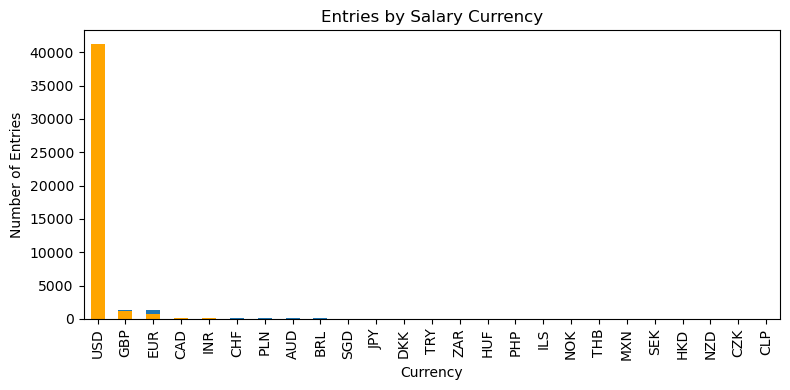

In [377]:
"""
Task 2
Count by Employee Residence
"""
print("Number of entries by employee residence:")
print(df['employee_residence'].value_counts())

"""
Count by Salary Currency
"""
print("\nNumber of entries by salary currency:")
print(df['salary_currency'].value_counts())

# Employee residence bar chart
df['employee_residence'].value_counts().plot(kind='bar', figsize=(10, 5), title='Entries by Employee Residence')
plt.xlabel('Country')
plt.ylabel('Number of Entries')
plt.tight_layout()
plt.savefig('comp3800p1_Jisoo_residence.pdf')

# Salary currency bar chart
df['salary_currency'].value_counts().plot(kind='bar', figsize=(8, 4), title='Entries by Salary Currency', color='orange')
plt.xlabel('Currency')
plt.ylabel('Number of Entries')
plt.tight_layout()
plt.savefig('comp3800p1_Jisoo_currency.pdf')



In [378]:
"""
Task 3
Salaries Paid in USD to Non-US Residents
"""
# Filter: salary_currency is USD AND employee_residence is NOT US
usd_non_us = df[(df['salary_currency'] == 'USD') & (df['employee_residence'] != 'US')]
print(f"Number of salaries paid in USD to professionals who do NOT reside in the US: {len(usd_non_us)}")

"""
Salaries NOT Paid in USD to US Residents
"""
# Filter: salary_currency is NOT USD AND employee_residence IS US
non_usd_us = df[(df['salary_currency'] != 'USD') & (df['employee_residence'] == 'US')]
print(f"Number of salaries NOT paid in USD to professionals who DO reside in the US: {len(non_usd_us)}")

Number of salaries paid in USD to professionals who do NOT reside in the US: 1978
Number of salaries NOT paid in USD to professionals who DO reside in the US: 35


In [379]:
"""
Task 4: Number of US-based entries with USD salary
"""

# 🇺🇸 Filter for US-based entries with USD salaries
df_us_usd = df[(df['employee_residence'] == 'US') & (df['salary_currency'] == 'USD')]

# 📊 Display the number of entries in the filtered subset
print(f"Number of US-based entries with USD salary: {len(df_us_usd)}")

# 🔍 Preview the first few rows
print(df_us_usd.head())

Number of US-based entries with USD salary: 39257
   work_year experience_level employment_type     job_title  salary  \
3       2024               SE              FT       Analyst   91500   
4       2024               SE              FT       Analyst   70000   
5       2024               MI              FT       Manager  110000   
6       2024               MI              FT       Manager   81500   
7       2024               SE              FT  Data Analyst   96600   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
3             USD          91500                 US             0   
4             USD          70000                 US             0   
5             USD         110000                 US             0   
6             USD          81500                 US             0   
7             USD          96600                 US             0   

  company_location company_size  
3               US            M  
4               US            M  
5     

Distribution of experience levels:
experience_level
SE    24104
MI    11127
EN     3168
EX      858
Name: count, dtype: int64


C:\Users\local_jyoon1\Temp\ipykernel_13988\1439883882.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_us_usd, x='experience_level', order=df_us_usd['experience_level'].value_counts().index, palette='Set2')


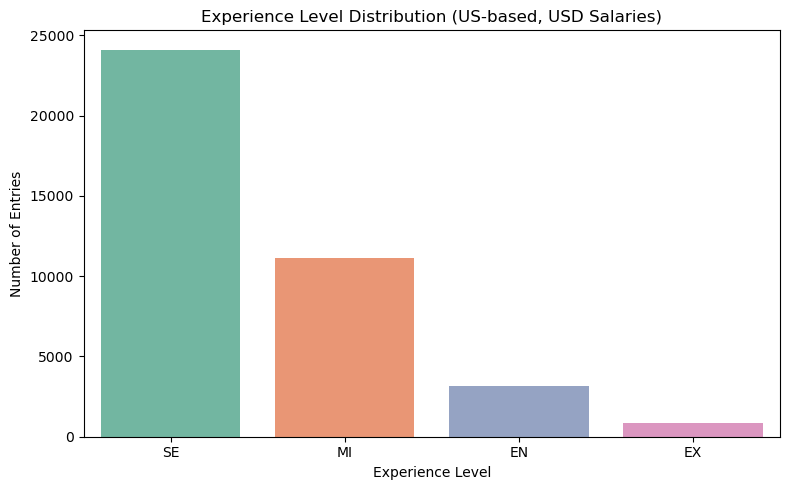

In [380]:
"""
Task 5: Analyzing and Visualizing US-Experience Level Distribution
"""

# Filter for US-based professionals paid in USD
df_us_usd = df[(df['employee_residence'] == 'US') & (df['salary_currency'] == 'USD')]

# Count of each experience level
print("Distribution of experience levels:")
print(df_us_usd['experience_level'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df_us_usd, x='experience_level', order=df_us_usd['experience_level'].value_counts().index, palette='Set2')
plt.title('Experience Level Distribution (US-based, USD Salaries)')
plt.xlabel('Experience Level')
plt.ylabel('Number of Entries')
plt.tight_layout()

# Save the plot
plt.savefig('comp3800p1_Jisoo_experience_distribution.pdf')  # or .png
plt.show()


Number of entries in full_usa_usd: 39170


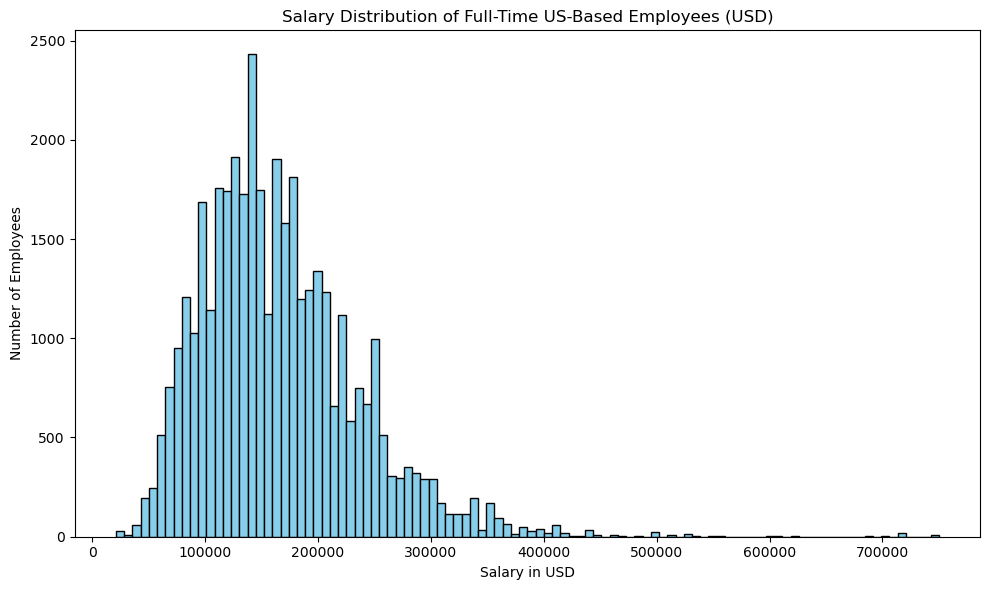

In [381]:
"""
Task 6: Plot Salary Distribution with 100 Bins
"""

# Filter for full-time US-based employees paid in USD
full_usa_usd = df[
    (df['employee_residence'] == 'US') &
    (df['salary_currency'] == 'USD') &
    (df['employment_type'] == 'FT')
]

print(f"Number of entries in full_usa_usd: {len(full_usa_usd)}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(full_usa_usd['salary_in_usd'], bins=100, color='skyblue', edgecolor='black')
plt.title('Salary Distribution of Full-Time US-Based Employees (USD)')
plt.xlabel('Salary in USD')
plt.ylabel('Number of Employees')
plt.tight_layout()

# Save the plot
plt.savefig('comp3800p1_Jisoo_salary_distribution.pdf')  # or .png
plt.show()


Salary Statistics (USD):
Mean: 166140.57
Median: 155000.00
Mode: 160000.00
Variance: 4973563526.24
Standard Deviation: 70523.50
Skewness: 1.34
Kurtosis: 4.77


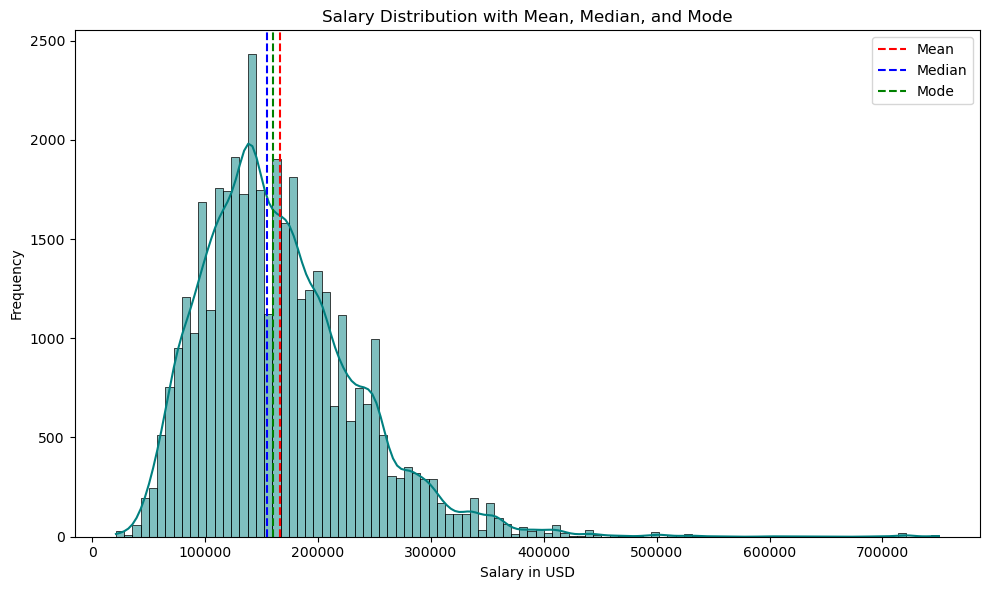

In [382]:
"""
Task 7: Compute Salary Statistics and Reinforcing a Plot
"""

# Compute statistics for salary_in_usd
mean_salary = full_usa_usd['salary_in_usd'].mean()
median_salary = full_usa_usd['salary_in_usd'].median()
mode_salary = full_usa_usd['salary_in_usd'].mode()[0]
variance_salary = full_usa_usd['salary_in_usd'].var()
std_salary = full_usa_usd['salary_in_usd'].std()
skewness_salary = full_usa_usd['salary_in_usd'].skew()
kurtosis_salary = full_usa_usd['salary_in_usd'].kurt()

# Display results
print("Salary Statistics (USD):")
print(f"Mean: {mean_salary:.2f}")
print(f"Median: {median_salary:.2f}")
print(f"Mode: {mode_salary:.2f}")
print(f"Variance: {variance_salary:.2f}")
print(f"Standard Deviation: {std_salary:.2f}")
print(f"Skewness: {skewness_salary:.2f}")
print(f"Kurtosis: {kurtosis_salary:.2f}")

# 📝 Interpretation:
# The mean salary is higher than the median, which suggests a right-skewed distribution.
# This is confirmed by the positive skewness value, indicating that a few high salaries are pulling the average up.
# The mode shows the most frequently occurring salary, which may be near entry-level or mid-level compensation.
# A high variance and standard deviation suggest a wide spread in salary values, meaning there's significant inequality.
# Positive kurtosis indicates a distribution with heavier tails—more extreme values than a normal distribution.
# Overall, the salary distribution is right-skewed with a few high-paying roles creating outliers.


import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(full_usa_usd['salary_in_usd'], bins=100, kde=True, color='teal')
plt.axvline(mean_salary, color='red', linestyle='--', label='Mean')
plt.axvline(median_salary, color='blue', linestyle='--', label='Median')
plt.axvline(mode_salary, color='green', linestyle='--', label='Mode')
plt.title('Salary Distribution with Mean, Median, and Mode')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('comp3800p1_Jisoo_salary_stats_overlay.pdf')
plt.show()

Number of entries for each job title:
job_title
Data Scientist                   7417
Data Engineer                    5963
Data Analyst                     4232
Machine Learning Engineer        3966
Software Engineer                3586
                                 ... 
Machine Learning Specialist         1
AI Research Engineer                1
Quantitative Research Analyst       1
Big Data Developer                  1
Principal Data Analyst              1
Name: count, Length: 204, dtype: int64

Top 5 most popular job titles:
['Data Scientist', 'Data Engineer', 'Data Analyst', 'Machine Learning Engineer', 'Software Engineer']


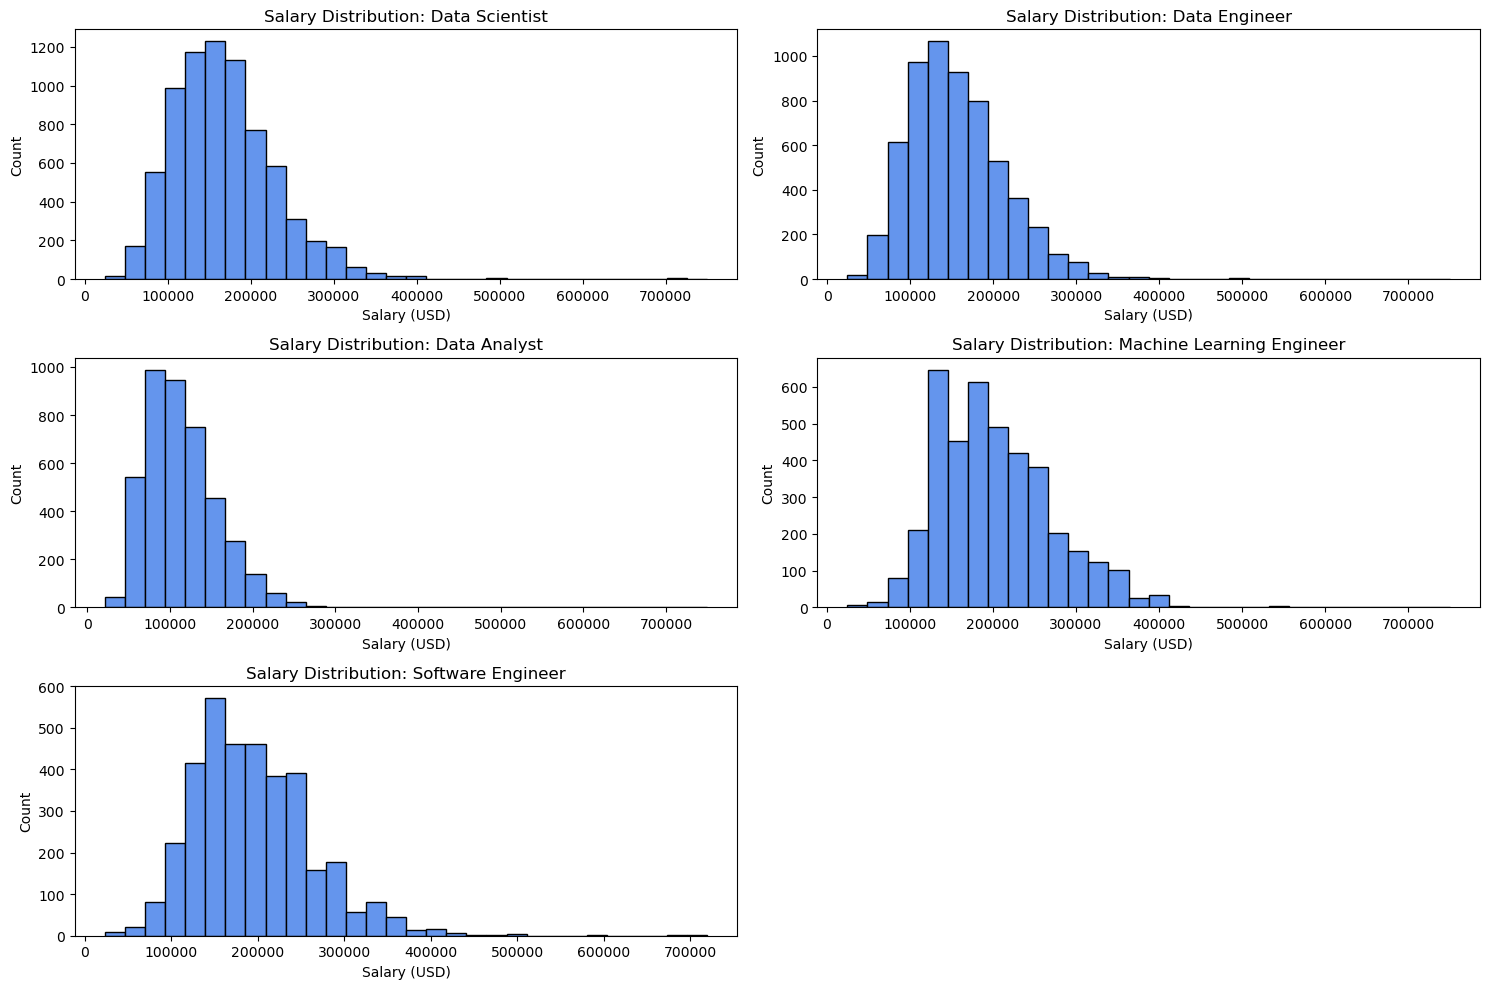

In [383]:
"""
Task 8: Top 5 Most Frequenct Job Title
"""

# Count job title frequency
job_counts = full_usa_usd['job_title'].value_counts()

print("Number of entries for each job title:")
print(job_counts)

# Get top 5 job titles
top_5_titles = job_counts.head(5).index.tolist()
print("\nTop 5 most popular job titles:")
print(top_5_titles)

import matplotlib.pyplot as plt

# Set up subplots
plt.figure(figsize=(15, 10))
for i, title in enumerate(top_5_titles, 1):
    plt.subplot(3, 2, i)
    subset = full_usa_usd[full_usa_usd['job_title'] == title]
    plt.hist(subset['salary_in_usd'], bins=30, color='cornflowerblue', edgecolor='black')
    plt.title(f'Salary Distribution: {title}')
    plt.xlabel('Salary (USD)')
    plt.ylabel('Count')

plt.tight_layout()
plt.savefig('comp3800p1_Jisoo_top5_jobtitle_salaries.pdf')
plt.show()


In [384]:
"""
Task 9: Use standard deviation to find most consistent salaries
"""

top_5_titles = full_usa_usd['job_title'].value_counts().head(5).index.tolist()

# Dictionary to store standard deviations
salary_std_by_title = {}

for title in top_5_titles:
    subset = full_usa_usd[full_usa_usd['job_title'] == title]
    std_dev = subset['salary_in_usd'].std()
    salary_std_by_title[title] = std_dev

# Display results
print("Standard deviation of salaries for top 5 job titles:")
for title, std in salary_std_by_title.items():
    print(f"{title}: {std:.2f}")


# 📝 Comment:
# To determine which job title has the most consistent salaries, I calculated the standard deviation of salaries for each of the top five most popular job titles.
# A lower standard deviation indicates that salaries are tightly clustered around the mean, meaning less variation and more consistency.
# Among these roles, the job title with the lowest standard deviation has the most predictable and uniform compensation.
# This could reflect standardized pay scales, clearer role definitions, or less variation in seniority within that title.

Standard deviation of salaries for top 5 job titles:
Data Scientist: 61746.02
Data Engineer: 58295.37
Data Analyst: 43820.55
Machine Learning Engineer: 69211.74
Software Engineer: 69275.72


In [385]:
"""
Task 10: Among the top 5 most popular job title, find the average of salary in the experience level to find most frequent value.
"""

top_5_titles = full_usa_usd['job_title'].value_counts().head(5).index.tolist()

# Create a dictionary to store average salaries by experience level for each title
experience_salary_map = {}

for title in top_5_titles:
    subset = full_usa_usd[full_usa_usd['job_title'] == title]
    avg_by_exp = subset.groupby('experience_level')['salary_in_usd'].mean().to_dict()
    experience_salary_map[title] = avg_by_exp

# Display results
for title, exp_salaries in experience_salary_map.items():
    print(f"\n{title}:")
    for level, avg_salary in exp_salaries.items():
        print(f"  {level}: ${avg_salary:.2f}")



Data Scientist:
  EN: $113921.76
  EX: $214543.70
  MI: $149912.33
  SE: $176858.51

Data Engineer:
  EN: $109461.97
  EX: $195871.87
  MI: $136892.95
  SE: $163603.40

Data Analyst:
  EN: $98097.63
  EX: $117104.17
  MI: $104243.80
  SE: $127583.02

Machine Learning Engineer:
  EN: $155756.11
  EX: $235615.00
  MI: $179636.78
  SE: $211381.88

Software Engineer:
  EN: $147704.37
  EX: $208469.46
  MI: $177390.05
  SE: $205353.95


C:\Users\local_jyoon1\Temp\ipykernel_13988\2948152151.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='work_setting', y='salary_in_usd', data=df, palette='Set2')


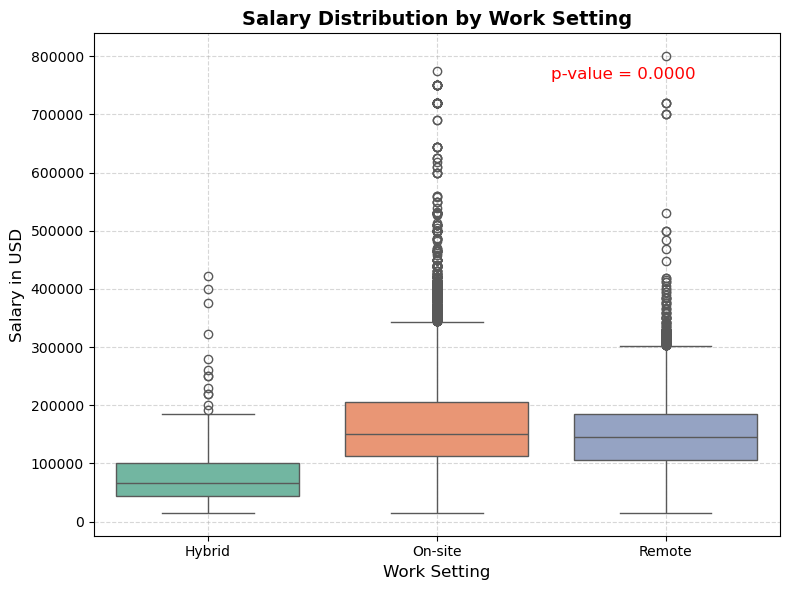

In [386]:
"""
Task 11
"""

# PROJECT 1
__author__ = 'COMP3800 P01'
__version__ = 'Fall 2025'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# Load dataset
df = pd.read_csv('salaries.csv')

# Filter to clear remote work categories
df = df[df['remote_ratio'].isin([0, 50, 100])]

# Map remote_ratio to readable labels
df['work_setting'] = df['remote_ratio'].map({
    0: 'On-site',
    50: 'Hybrid',
    100: 'Remote'
})

# Group salary data by work setting
groups = [df[df['work_setting'] == setting]['salary_in_usd'] for setting in ['On-site', 'Hybrid', 'Remote']]

# Apply Kruskal-Wallis test
stat, p_value = kruskal(*groups)

plt.figure(figsize=(8, 6))
sns.boxplot(x='work_setting', y='salary_in_usd', data=df, palette='Set2')

# Title and labels
plt.title('Salary Distribution by Work Setting', fontsize=14, fontweight='bold')
plt.xlabel('Work Setting', fontsize=12)
plt.ylabel('Salary in USD', fontsize=12)

# Gridlines for clarity
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight p-value
plt.text(1.5, df['salary_in_usd'].max() * 0.95, f'p-value = {p_value:.4f}', color='red', fontsize=12)

# Clean layout
plt.tight_layout()
plt.savefig('comp3800p1_Jisoo.pdf')
plt.show()